# 04 - LeGrad-HuBERT Temporal Explanation

This notebook validates the new LeGrad-style HuBERT implementation on one real IEMOCAP utterance. It keeps the existing rollout pipeline separate and focuses on the LeGrad-specific choices:

- score source: final HuBERT score or layer-local score;
- layer aggregation: mean over Transformer layers or renormalized HuBERT layer weights;
- token axis: source/key time tokens;
- formula: `ReLU(d score / d attention)`;
- method family: LeGrad positive attention-gradient reduction;
- outputs: sum-normalized scores for evaluation and min-max scores for visualization;
- pooling: HuBERT-style temporal mean pooling, masked when a feature mask exists.


## Setup

The notebook uses the same project utilities as the scripts. It prefers the IEMOCAP utterance `Ses01F_impro01_F005`, because this example is already used in the progress report and Notebook 01 discussion.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.load_model import load_hubert_emotion_model
from src.utils.audio import load_audio_mono_16k
from src.explainers.transformer_relevance.legrad_hubert import (
    LEGRAD_FINAL_SCORE_HUBERT_WEIGHTED_SOURCE_TOKENS,
    LEGRAD_FINAL_SCORE_MEAN_LAYERS_SOURCE_TOKENS,
    LEGRAD_HUBERT_EXPLANATION_MODES,
    LEGRAD_LAYER_LOCAL_SCORE_HUBERT_WEIGHTED_SOURCE_TOKENS,
    LEGRAD_LAYER_LOCAL_SCORE_MEAN_LAYERS_SOURCE_TOKENS,
    extract_legrad_hubert_relevance,
)
from src.explainers.transformer_relevance.token_mapping import temporal_relevance_to_dataframe
from src.explainers.transformer_relevance.visualization import (
    plot_relevance_timeline,
    plot_waveform_with_interval_scores,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TARGET_AUDIO_ID = "Ses01F_impro01_F005"
PRIMARY_LEGRAD_MODE = LEGRAD_LAYER_LOCAL_SCORE_HUBERT_WEIGHTED_SOURCE_TOKENS
print("Device:", DEVICE)
print("Primary LeGrad-HuBERT mode:", PRIMARY_LEGRAD_MODE)

C:\Users\mateu\repos\gradient_based_speach_xai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
Primary LeGrad-HuBERT mode: legrad_layer_local_score_relu_attention_gradient_renormalized_hubert_layer_weighted_source_tokens


## Load One Audio And The HuBERT Classifier

The model load allows remote files because some local Hugging Face caches may contain the weights and config but not the feature extractor file. Once cached, later runs are normally fast.

In [2]:
metadata = pd.read_csv(PROJECT_ROOT / "data" / "metadata.csv")
selected = metadata.loc[metadata["audio_id"].eq(TARGET_AUDIO_ID)].iloc[0]
audio_path = Path(selected["audio_path"])
if not audio_path.exists():
    audio_path = PROJECT_ROOT / "data" / "Session1" / "sentences" / "wav" / "Ses01F_impro01" / f"{TARGET_AUDIO_ID}.wav"
if not audio_path.exists():
    raise FileNotFoundError(audio_path)

waveform, sampling_rate = load_audio_mono_16k(str(audio_path))
audio_duration = waveform.numel() / sampling_rate
model, processor, device = load_hubert_emotion_model(device=DEVICE, local_files_only=False)
class_names = [str(model.config.id2label[index]) for index in range(model.config.num_labels)]

print("Audio path:", audio_path)
print("True label from metadata:", selected["true_label"])
print("Waveform shape:", tuple(waveform.shape))
print("Sampling rate:", sampling_rate)
print("Duration seconds:", round(audio_duration, 3))
print("Model labels:", class_names)

Audio path: C:\Users\mateu\repos\gradient_based_speach_xai\data\Session1\sentences\wav\Ses01F_impro01\Ses01F_impro01_F005.wav
True label from metadata: neu
Waveform shape: (64479,)
Sampling rate: 16000
Duration seconds: 4.03
Model labels: ['neu', 'hap', 'ang', 'sad']


## Compute LeGrad-HuBERT Relevance

This cell performs the important implementation checks in one call:

1. runs HuBERT with attentions and hidden states enabled;
2. builds the real final-score gradients;
3. builds the layer-local scores `H_l -> projector -> temporal pooling -> classifier`;
4. reduces positive attention gradients to source-token relevance;
5. aggregates layers with both mean and renormalized HuBERT layer weights.

In [3]:
legrad_result = extract_legrad_hubert_relevance(
    model=model,
    processor=processor,
    waveform=waveform,
    sampling_rate=sampling_rate,
    device=device,
)

target_class = legrad_result["target_class"]
predicted_class = legrad_result["predicted_class"]
logits = legrad_result["logits"].squeeze(0)
probabilities = torch.softmax(logits, dim=-1)

prediction_table = pd.DataFrame(
    {
        "class_id": list(range(len(class_names))),
        "label": class_names,
        "logit": logits.detach().cpu().numpy(),
        "probability": probabilities.detach().cpu().numpy(),
    }
)

print("Predicted class:", predicted_class, class_names[predicted_class])
print("Target class explained:", target_class, class_names[target_class])
display(prediction_table.style.format({"logit": "{:.4f}", "probability": "{:.4f}"}))

Predicted class: 2 ang
Target class explained: 2 ang


,class_id,label,logit,probability
0,0,neu,-0.6679,0.0885
1,1,hap,0.7522,0.3660
2,2,ang,1.1024,0.5195
3,3,sad,-1.8942,0.0260


## Intermediate Shape Checks

The two layer-relevance tensors should both have shape `[batch, 12, time]`. The 12 dimension corresponds to the Transformer attention layers. `H_0` participates in HuBERT's layer mixture, but it has no attention map, so it is not a LeGrad attention layer.

In [4]:
shape_rows = [
    {
        "object": "final_score_layer_relevance",
        "shape": tuple(legrad_result["final_score_layer_relevance"].shape),
        "meaning": "ReLU(d final_score / d A_l) reduced to source tokens for each layer",
    },
    {
        "object": "layer_local_score_layer_relevance",
        "shape": tuple(legrad_result["layer_local_score_layer_relevance"].shape),
        "meaning": "ReLU(d layer_score_l / d A_l) reduced to source tokens for each layer",
    },
    {
        "object": "renormalized_hubert_layer_weights",
        "shape": tuple(legrad_result["renormalized_hubert_layer_weights"].shape),
        "meaning": "softmax(layer_weights)[1:13], renormalized over Transformer layers only",
    },
    {
        "object": "minmax_visual_scores[primary_mode]",
        "shape": tuple(legrad_result["minmax_visual_scores"][PRIMARY_LEGRAD_MODE].shape),
        "meaning": "paper-style min-max normalized temporal scores for visualization; evaluation scores remain sum-normalized",
    },
]
shape_table = pd.DataFrame(shape_rows)
display(
    shape_table.style
    .set_properties(subset=["object", "meaning"], **{"text-align": "left"})
    .set_properties(subset=["object", "shape"], **{"white-space": "nowrap"})
    .set_properties(subset=["meaning"], **{"white-space": "normal", "min-width": "560px"})
    .hide(axis="index")
)

assert legrad_result["final_score_layer_relevance"].shape[1] == 12
assert legrad_result["layer_local_score_layer_relevance"].shape[1] == 12
assert torch.isclose(legrad_result["renormalized_hubert_layer_weights"].sum(), torch.tensor(1.0, device=legrad_result["renormalized_hubert_layer_weights"].device))
assert legrad_result["minmax_visual_scores"][PRIMARY_LEGRAD_MODE].shape == legrad_result["scores"][PRIMARY_LEGRAD_MODE].shape

object,shape,meaning
final_score_layer_relevance,"(1, 12, 201)",ReLU(d final_score / d A_l) reduced to source tokens for each layer
layer_local_score_layer_relevance,"(1, 12, 201)",ReLU(d layer_score_l / d A_l) reduced to source tokens for each layer
renormalized_hubert_layer_weights,"(12,)","softmax(layer_weights)[1:13], renormalized over Transformer layers only"
minmax_visual_scores[primary_mode],"(1, 201)",paper-style min-max normalized temporal scores for visualization; evaluation scores remain sum-normalized


## Layer Weights And Layer-Local Scores

The HuBERT layer coefficients are used only for aggregating already-computed layer relevance maps. They are not the class-dependent scalar used to take gradients. The layer-local scalar is the target-class logit obtained by passing one `H_l` through the existing projector, temporal pooling, and classifier.

In [5]:
layer_ids = np.arange(1, legrad_result["num_attention_layers"] + 1)
layer_weight_table = pd.DataFrame(
    {
        "attention_layer": layer_ids,
        "renormalized_hubert_layer_weight": legrad_result["renormalized_hubert_layer_weights"].detach().cpu().numpy(),
        "layer_local_target_logit": legrad_result["layer_local_scores"].squeeze(0).detach().cpu().numpy(),
    }
)
display(layer_weight_table.style.format({
    "renormalized_hubert_layer_weight": "{:.6f}",
    "layer_local_target_logit": "{:.4f}",
}))

,attention_layer,renormalized_hubert_layer_weight,layer_local_target_logit
0,1,0.073140,3.8775
1,2,0.082474,-0.4792
2,3,0.079083,0.9722
3,4,0.077485,0.6156
4,5,0.078225,0.1605
5,6,0.081234,0.8504
6,7,0.080198,0.3722
7,8,0.086560,0.4108
8,9,0.089356,0.4399
9,10,0.091365,0.3940


## Compare The Four Explicit LeGrad-HuBERT Modes

The mode names are intentionally long so the methodological choices are visible in result tables and filenames.

In [6]:
mode_summary_rows = []
for mode in LEGRAD_HUBERT_EXPLANATION_MODES:
    scores = legrad_result["scores"][mode].squeeze(0)
    visual_scores = legrad_result["minmax_visual_scores"][mode].squeeze(0)
    mode_summary_rows.append(
        {
            "mode": mode,
            "shape": tuple(legrad_result["scores"][mode].shape),
            "evaluation_sum": float(scores.sum().item()),
            "evaluation_min": float(scores.min().item()),
            "evaluation_max": float(scores.max().item()),
            "visual_min": float(visual_scores.min().item()),
            "visual_max": float(visual_scores.max().item()),
            "finite": bool(torch.isfinite(scores).all().item()),
            "top_token": int(torch.argmax(scores).item()),
        }
    )
mode_summary = pd.DataFrame(mode_summary_rows)
display(mode_summary.style.format({
    "evaluation_sum": "{:.6f}",
    "evaluation_min": "{:.6f}",
    "evaluation_max": "{:.6f}",
    "visual_min": "{:.6f}",
    "visual_max": "{:.6f}",
}))

for mode in LEGRAD_HUBERT_EXPLANATION_MODES:
    scores = legrad_result["scores"][mode]
    visual_scores = legrad_result["minmax_visual_scores"][mode]
    assert torch.isfinite(scores).all()
    assert torch.isfinite(visual_scores).all()
    assert torch.allclose(scores.sum(dim=-1), torch.ones(scores.shape[0], device=scores.device), atol=1e-5)
    assert visual_scores.min() >= 0
    assert visual_scores.max() <= 1 + 1e-6

,mode,shape,evaluation_sum,evaluation_min,evaluation_max,visual_min,visual_max,finite,top_token
0,legrad_final_score_relu_attention_gradient_mean_layers_source_tokens,"(1, 201)",1.000000,0.003899,0.006013,0.000000,1.000000,True,122
1,legrad_final_score_relu_attention_gradient_renormalized_hubert_layer_weighted_source_tokens,"(1, 201)",1.000000,0.003899,0.006006,0.000000,1.000000,True,122
2,legrad_layer_local_score_relu_attention_gradient_mean_layers_source_tokens,"(1, 201)",1.000000,0.003423,0.006905,0.000000,1.000000,True,81
3,legrad_layer_local_score_relu_attention_gradient_renormalized_hubert_layer_weighted_source_tokens,"(1, 201)",1.000000,0.003395,0.006881,0.000000,1.000000,True,81


## Top Temporal Tokens For The Primary Mode

The primary mode here uses layer-local LeGrad scores and renormalized HuBERT layer weights. The table maps HuBERT tokens uniformly back to the audio duration, which is the same approximation used by the existing temporal relevance pipeline.

In [7]:
primary_scores = legrad_result["scores"][PRIMARY_LEGRAD_MODE]
primary_visual_scores = legrad_result["minmax_visual_scores"][PRIMARY_LEGRAD_MODE]
primary_relevance = temporal_relevance_to_dataframe(primary_scores, audio_duration)
primary_visual_relevance = temporal_relevance_to_dataframe(primary_visual_scores, audio_duration)
primary_relevance["visual_relevance"] = primary_visual_relevance["relevance"]
primary_relevance.insert(0, "audio_id", TARGET_AUDIO_ID)
primary_relevance.insert(1, "explanation_mode", PRIMARY_LEGRAD_MODE)
primary_relevance.insert(2, "target_class", target_class)
primary_relevance.insert(3, "target_label", class_names[target_class])

top_tokens = primary_relevance.sort_values("relevance", ascending=False).head(12).reset_index(drop=True)
display(top_tokens.style.format({
    "start_time": "{:.3f}",
    "end_time": "{:.3f}",
    "relevance": "{:.6f}",
    "visual_relevance": "{:.6f}",
}))

,audio_id,explanation_mode,target_class,target_label,token_idx,start_time,end_time,relevance,visual_relevance
0,Ses01F_impro01_F005,legrad_layer_local_score_relu_attention_gradient_renormalized_hubert_layer_weighted_source_tokens,2,ang,81,1.624,1.644,0.006881,1.000000
1,Ses01F_impro01_F005,legrad_layer_local_score_relu_attention_gradient_renormalized_hubert_layer_weighted_source_tokens,2,ang,30,0.601,0.622,0.006735,0.958157
2,Ses01F_impro01_F005,legrad_layer_local_score_relu_attention_gradient_renormalized_hubert_layer_weighted_source_tokens,2,ang,128,2.566,2.586,0.006562,0.908456
3,Ses01F_impro01_F005,legrad_layer_local_score_relu_attention_gradient_renormalized_hubert_layer_weighted_source_tokens,2,ang,96,1.925,1.945,0.006495,0.889246
4,Ses01F_impro01_F005,legrad_layer_local_score_relu_attention_gradient_renormalized_hubert_layer_weighted_source_tokens,2,ang,53,1.063,1.083,0.006434,0.871722
5,Ses01F_impro01_F005,legrad_layer_local_score_relu_attention_gradient_renormalized_hubert_layer_weighted_source_tokens,2,ang,97,1.945,1.965,0.006374,0.854441
6,Ses01F_impro01_F005,legrad_layer_local_score_relu_attention_gradient_renormalized_hubert_layer_weighted_source_tokens,2,ang,122,2.446,2.466,0.006287,0.829551
7,Ses01F_impro01_F005,legrad_layer_local_score_relu_attention_gradient_renormalized_hubert_layer_weighted_source_tokens,2,ang,86,1.724,1.744,0.006259,0.821496
8,Ses01F_impro01_F005,legrad_layer_local_score_relu_attention_gradient_renormalized_hubert_layer_weighted_source_tokens,2,ang,79,1.584,1.604,0.006237,0.815120
9,Ses01F_impro01_F005,legrad_layer_local_score_relu_attention_gradient_renormalized_hubert_layer_weighted_source_tokens,2,ang,80,1.604,1.624,0.006237,0.815093


## Notebook-01-Style Visualization

This final visualization uses the same two-panel idea as Notebook 01: waveform on top and interval scores below, sharing the same time axis. Here the intervals are HuBERT temporal tokens instead of SpeechXAI word spans, and the plotted scores use the paper-style min-max normalization while the evaluation scores remain sum-normalized.

C:\Users\mateu\repos\gradient_based_speach_xai\src\explainers\transformer_relevance\visualization.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  figure.tight_layout(rect=[0, 0, 1, 0.93])


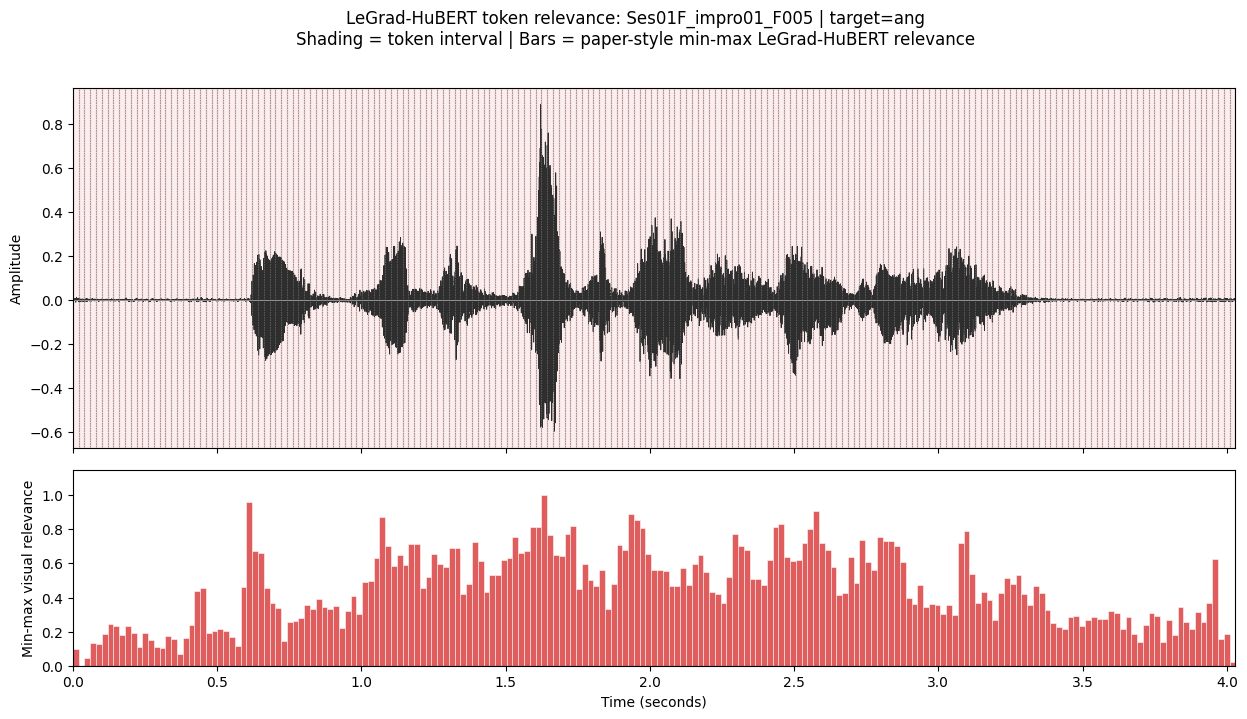

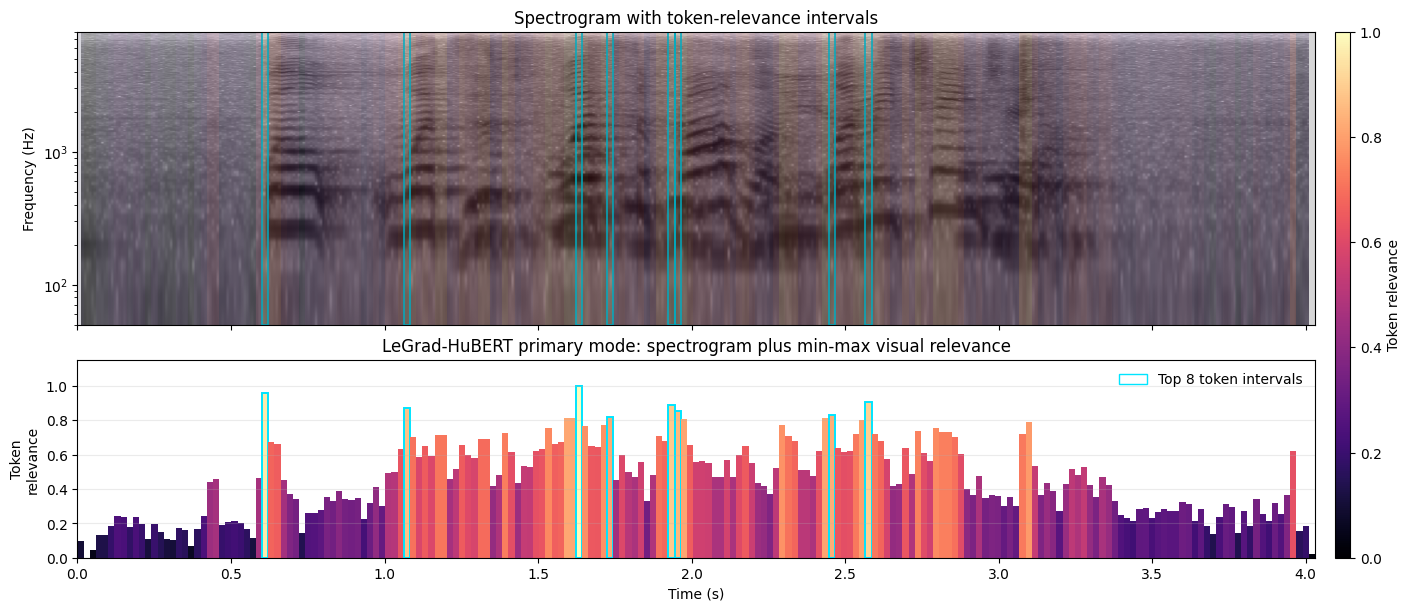

In [8]:
primary_visual_plot = primary_relevance.copy()
primary_visual_plot["relevance"] = primary_visual_plot["visual_relevance"]

plot_waveform_with_interval_scores(
    waveform=waveform,
    sampling_rate=sampling_rate,
    intervals=primary_visual_plot,
    score_column="relevance",
    start_column="start_time",
    end_column="end_time",
    title=(
        f"LeGrad-HuBERT token relevance: {TARGET_AUDIO_ID} | "
        f"target={class_names[target_class]}\n"
        "Shading = token interval | Bars = paper-style min-max LeGrad-HuBERT relevance"
    ),
    score_label="Min-max visual relevance",
)

plot_relevance_timeline(
    waveform=waveform,
    sampling_rate=sampling_rate,
    df_relevance=primary_visual_plot,
    relevance_title="LeGrad-HuBERT primary mode: spectrogram plus min-max visual relevance",
    top_k=8,
)

## Result

The notebook validates that the LeGrad-HuBERT implementation can compute final-score and layer-local attention-gradient relevance, aggregate layers with mean or HuBERT weights, normalize temporal scores, and visualize the result on the waveform timeline.